In [37]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

Step 1: Understand Your Data
Business Purpose: Familiarize yourself with who your customers are and what attributes
are available to you.
● Load and preview the dataset.
● Check data types, unique values, and presence of nulls.
● Understand which variables are categorical and which are numerical.

In [38]:
df = pd.read_csv(r"C:\Users\91987\Downloads\US_Customer_Insights_Dataset.csv")

In [39]:
df.head()

,CustomerID,Name,State,Education,Gender,Age,Married,NumPets,JoinDate,TransactionDate,MonthlySpend,DaysSinceLastInteraction
0,CUST10319,Scott Perez,Florida,High School,Non-Binary,47,Yes,1,9/19/21,9/2/24,1281.74,332
1,CUST10695,Jennifer Burton,Washington,Master,Male,72,Yes,0,4/5/24,6/2/24,429.46,424
2,CUST10297,Michelle Rogers,Arizona,Master,Female,40,Yes,2,7/24/24,2/28/25,510.34,153
3,CUST10103,Brooke Hendricks,Texas,Master,Male,27,Yes,0,8/12/23,3/29/25,396.47,124
4,CUST10219,Karen Johns,Texas,High School,Female,28,Yes,1,12/6/21,7/24/22,139.68,1103


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10675 entries, 0 to 10674
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                10675 non-null  object 
 1   Name                      10675 non-null  object 
 2   State                     10675 non-null  object 
 3   Education                 10675 non-null  object 
 4   Gender                    10675 non-null  object 
 5   Age                       10675 non-null  int64  
 6   Married                   10675 non-null  object 
 7   NumPets                   10675 non-null  int64  
 8   JoinDate                  10675 non-null  object 
 9   TransactionDate           10675 non-null  object 
 10  MonthlySpend              10675 non-null  float64
 11  DaysSinceLastInteraction  10675 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 1000.9+ KB


In [41]:
df.isnull().sum()

CustomerID                  0
Name                        0
State                       0
Education                   0
Gender                      0
Age                         0
Married                     0
NumPets                     0
JoinDate                    0
TransactionDate             0
MonthlySpend                0
DaysSinceLastInteraction    0
dtype: int64

In [42]:
categorical_cols = df.select_dtypes(include = 'object')

In [43]:
numerical_cols = df.select_dtypes(include = 'number')

Step 2: Descriptive Statistics
Business Purpose: Describe your customer base — how old are they, how much do they
spend, are they active?
● Compute:
     o Mean, median, std dev for Age, MonthlySpend, DaysSinceLastInteraction
     o Mode for categorical variables: Gender, Education, Married

In [44]:
print(df['Age'].mean())
print(df['Age'].median())
print(df['Age'].std())

49.47456674473068
49.0
18.22136549414863


**Insight** : Age appears to follow a fairly symmetric distribution, with no significant skewness observed.

In [45]:
print(df['MonthlySpend'].mean())
print(df['MonthlySpend'].median())
print(df['MonthlySpend'].std())

331.61031475409834
282.11
225.7992527582449


**Insight** : Monthly Spend is right-skewed, suggesting the presence of some customers with significantly higher spending than the majority.

In [46]:
print(df['DaysSinceLastInteraction'].mean())
print(df['DaysSinceLastInteraction'].median())
print(df['DaysSinceLastInteraction'].std())

538.4698829039812
445.0
398.7667466311463


**Insight** : DaysSinceLastInteraction is right-skewed, suggesting the presence of customers with exceptionally long periods of inactivity.

Step 3: Data Visualization
Business Purpose: Reveal patterns that numbers alone can’t show.
● Plot histograms and boxplots for Age, MonthlySpend

Text(0.5, 0, 'Age')

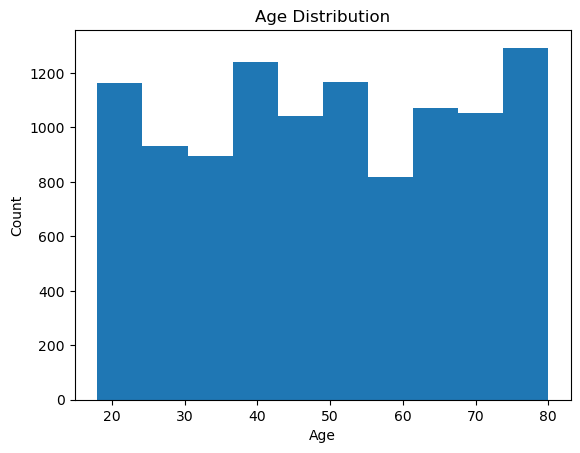

In [47]:
plt.hist(df['Age'])
plt.title("Age Distribution")
plt.ylabel("Count")
plt.xlabel("Age")

**Insight** : The histogram supports the descriptive statistics, showing a relatively balanced age distribution with no significant skewness.

Text(0, 0.5, 'Age (Years)')

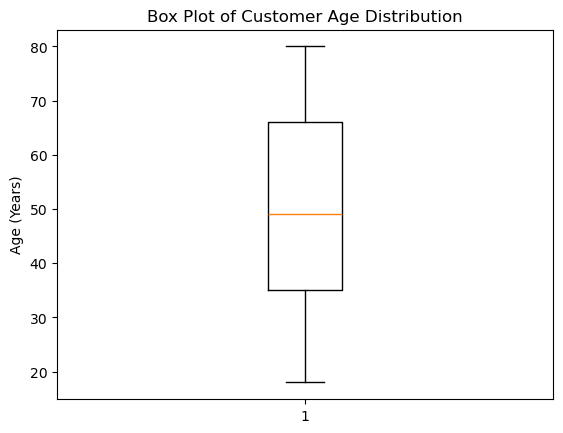

In [48]:
plt.boxplot(df["Age"])
plt.title('Box Plot of Customer Age Distribution')
plt.ylabel('Age (Years)')

**Insight** : The Age distribution shows no major outliers, with a median age of around 49 years and a wide spread of customers across different age groups.

Text(0.5, 0, 'Monthly Spend')

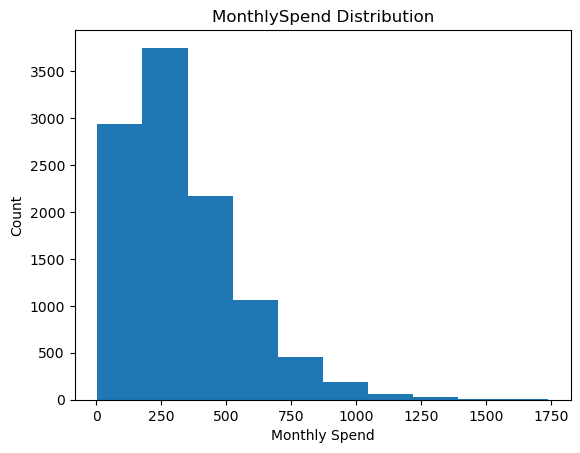

In [49]:
plt.hist(df['MonthlySpend'])
plt.title("MonthlySpend Distribution")
plt.ylabel("Count")
plt.xlabel("Monthly Spend")

**Insight** : Monthly Spend is right-skewed, indicating that while most customers have moderate spending levels, a few high-value customers contribute significantly higher amounts.

Text(0.5, 1.0, 'Box Plot of Monthly Customer Spend')

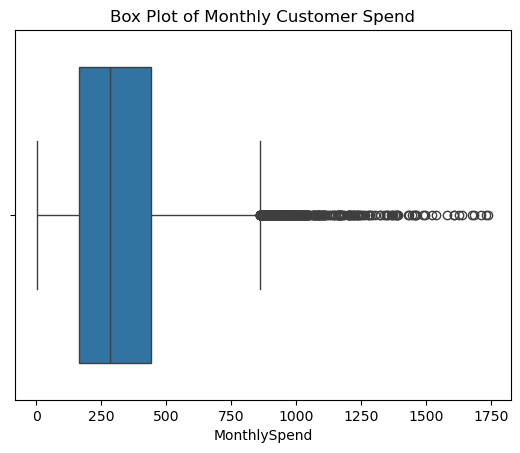

In [50]:
sns.boxplot(x= df["MonthlySpend"], data=df)
plt.title('Box Plot of Monthly Customer Spend')

**Insight** : Monthly Spend exhibits several high-spending outliers and a right-skewed distribution, suggesting the presence of a small but valuable segment of premium customers.

● Create a bar chart for Gender, Education, State

Text(0, 0.5, 'Count')

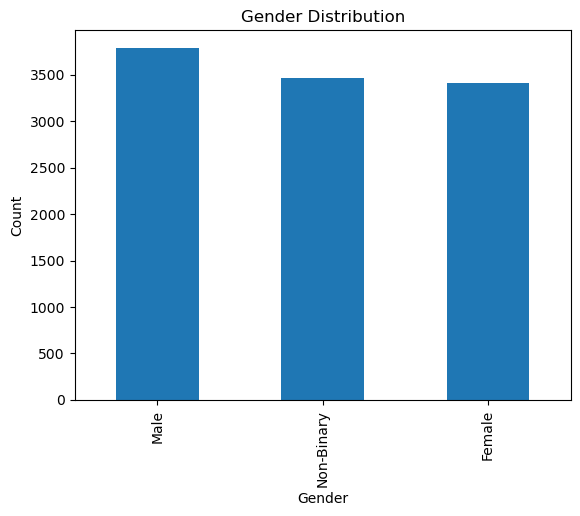

In [51]:
df['Gender'].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.ylabel("Count")

**Insight** : The count of males is highest in the data, followed by non-binary and female.

Text(0, 0.5, 'Number of Customers')

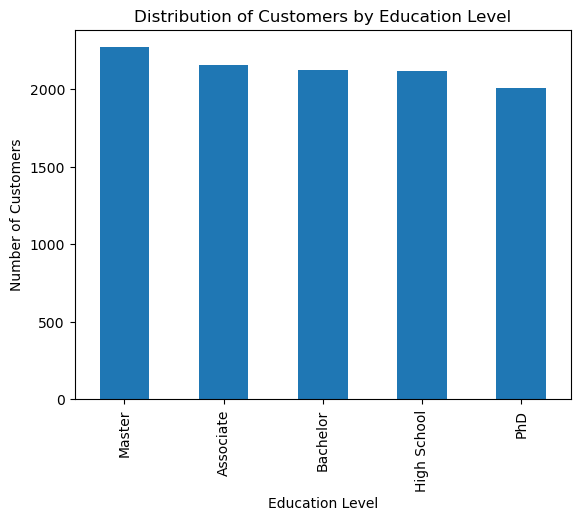

In [52]:
df['Education'].value_counts().plot(kind = "bar")
plt.title('Distribution of Customers by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Number of Customers')

**Insight** : Customers come from diverse educational backgrounds, with Master's degree holders being slightly more prevalent than other education levels.

Text(0.5, 1.0, 'Customer Distribution by State')

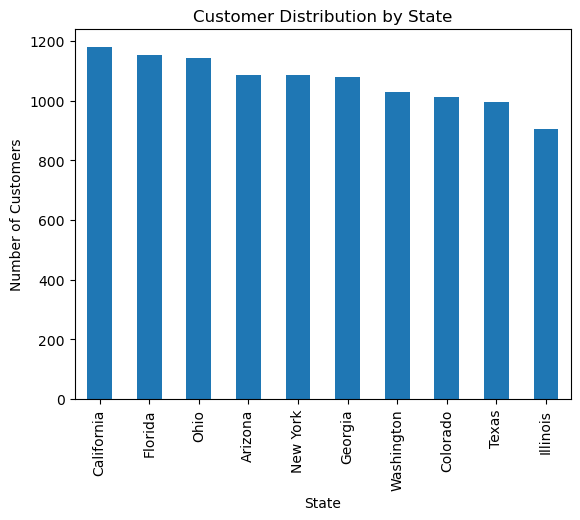

In [53]:
df['State'].value_counts().plot(kind = "bar")
plt.ylabel('Number of Customers')
plt.title('Customer Distribution by State')

**Insight** : The customer base is geographically diverse, with California contributing the largest share of customers, while Illinois has the fewest customers in the dataset.

● Scatterplot: Age vs MonthlySpend

● KDE: Spending behavior by education level or marital status

Text(0.5, 1.0, 'Relationship Between Customer Age and Monthly Spend')

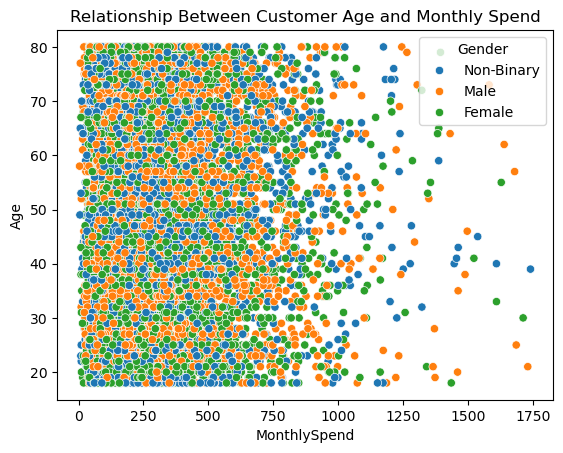

In [54]:
sns.scatterplot(x=df['MonthlySpend'], y=df['Age'], hue=df['Gender'])
plt.title('Relationship Between Customer Age and Monthly Spend')

**Insight** : There appears to be little to no correlation between customer age and monthly spending, indicating that spending patterns are relatively independent of age.

<Axes: xlabel='MonthlySpend', ylabel='Density'>

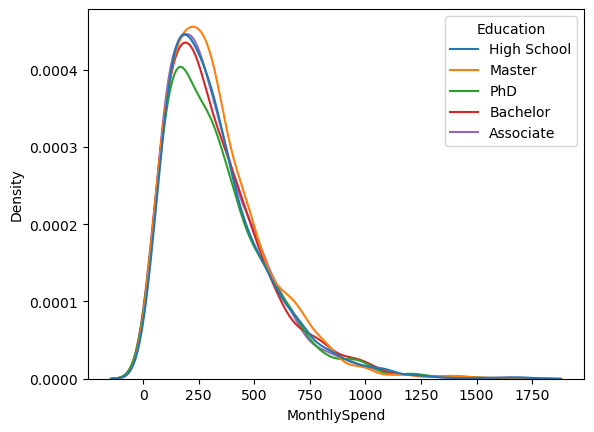

In [55]:
sns.kdeplot(data = df, x = "MonthlySpend",hue = 'Education')

**Insight** : Monthly spending patterns are largely consistent across education levels, suggesting that education is not a major factor influencing customer spending.

<Axes: xlabel='MonthlySpend', ylabel='Density'>

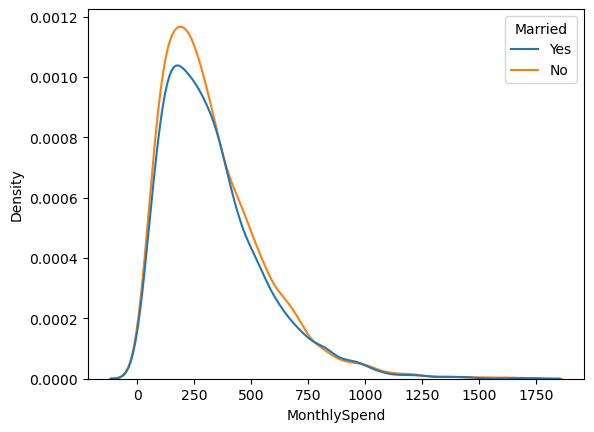

In [56]:
sns.kdeplot(data = df, x = "MonthlySpend",hue = 'Married')

**Insight** : Unmarried are spending more.

Step 4: Bivariate Analysis
Business Purpose: Check how customer attributes relate to one another.
● Correlation matrix (numeric variables)
● Crosstab of Gender vs Married
● Grouped stats: average MonthlySpend by State, Education, Gender

In [57]:
df.columns

Index(['CustomerID', 'Name', 'State', 'Education', 'Gender', 'Age', 'Married',
       'NumPets', 'JoinDate', 'TransactionDate', 'MonthlySpend',
       'DaysSinceLastInteraction'],
      dtype='object')

In [58]:
df[['NumPets','MonthlySpend','DaysSinceLastInteraction','Age']].corr()

,NumPets,MonthlySpend,DaysSinceLastInteraction,Age
NumPets,1.000000,0.020647,-0.055227,-0.023035
MonthlySpend,0.020647,1.000000,0.006081,-0.012323
DaysSinceLastInteraction,-0.055227,0.006081,1.000000,-0.003970
Age,-0.023035,-0.012323,-0.003970,1.000000


**Conclusion** : All variables have correlation coefficients near 0, meaning there are no linear relationships between them—none of these factors significantly influence or predict the others.

In [59]:
pd.crosstab(df['Gender'],df['Married'])

Married,No,Yes
Gender,,
Female,1797,1616
Male,1892,1899
Non-Binary,1894,1577


In [60]:
df.groupby('State')['MonthlySpend'].mean()

State
Arizona       341.489135
California    339.183492
Colorado      323.083462
Florida       327.696892
Georgia       328.354648
Illinois      332.589591
New York      332.151244
Ohio          340.187860
Texas         319.506770
Washington    329.444078
Name: MonthlySpend, dtype: float64

**Conclusion** : The average Monthly Spend is relatively consistent across all states, ranging from approximately 319 to 341. Arizona and California have the highest average spending, while Texas has the lowest. The small differences suggest that customer spending behavior is fairly similar across geographic regions.

In [61]:
df.groupby('Education')['MonthlySpend'].mean()

Education
Associate      327.884408
Bachelor       331.884753
High School    332.215712
Master         334.252305
PhD            331.690090
Name: MonthlySpend, dtype: float64

**Conclusion** : Average monthly spending is similar across all education levels, indicating that education has little impact on customer spending behavior.

In [62]:
df.groupby('Gender')['MonthlySpend'].mean()

Gender
Female        331.361310
Male          333.174068
Non-Binary    330.147240
Name: MonthlySpend, dtype: float64

**Conclusion** : Average monthly spending is nearly identical across genders, suggesting that gender has little influence on customer spending behavior.

Step 5: Formulate Hypotheses
Business Purpose: Turn business questions into statistical tests.

For all tests below, we use a significance level of **alpha = 0.05**. If the p-value is less than alpha, we reject the null hypothesis; otherwise, we fail to reject it.

In [63]:
df.head()

,CustomerID,Name,State,Education,Gender,Age,Married,NumPets,JoinDate,TransactionDate,MonthlySpend,DaysSinceLastInteraction
0,CUST10319,Scott Perez,Florida,High School,Non-Binary,47,Yes,1,9/19/21,9/2/24,1281.74,332
1,CUST10695,Jennifer Burton,Washington,Master,Male,72,Yes,0,4/5/24,6/2/24,429.46,424
2,CUST10297,Michelle Rogers,Arizona,Master,Female,40,Yes,2,7/24/24,2/28/25,510.34,153
3,CUST10103,Brooke Hendricks,Texas,Master,Male,27,Yes,0,8/12/23,3/29/25,396.47,124
4,CUST10219,Karen Johns,Texas,High School,Female,28,Yes,1,12/6/21,7/24/22,139.68,1103


## Do males and females spend differently? 

Null Hypothesis: The mean monthly spend of males is equal to the mean monthly spend of females.  
Alternate Hypothesis: The mean monthly spend of males is not equal to the mean monthly spend of females.

In [64]:
male = df.loc[df['Gender'] == 'Male','MonthlySpend']
female = df.loc[df['Gender'] == 'Female','MonthlySpend']

In [65]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(male, female, equal_var = False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 0.3391303706925083
p-value: 0.7345215220030699


The p-value is greater than alpha (0.05), so we fail to reject the null hypothesis. There is no statistically significant difference in monthly spend between males and females.

## Does education level impact average monthly spend?

Null Hypothesis: The mean Monthly Spend is equal across all education levels.  
Alternate Hypothesis: The mean Monthly Spend is not equal across all education levels.

In [66]:
phd = df.loc[df['Education']=='PhD','MonthlySpend']
master = df.loc[df['Education']=='Master','MonthlySpend']
bachelor = df.loc[df['Education']=='Bachelor','MonthlySpend']
associate = df.loc[df['Education']=='Associate','MonthlySpend']
highschool = df.loc[df['Education']=='High School','MonthlySpend']

In [67]:
from scipy.stats import f_oneway

f_stat, p_value = f_oneway(phd, master, bachelor, associate, highschool)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 0.2288066867370917
p-value: 0.922359467759936


The p-value is greater than alpha (0.05), so we fail to reject the null hypothesis. Education level does not have a statistically significant effect on monthly spend.

## Is marital status related to the number of pets owned? [Only for DS Students] 

Null Hypothesis : Marital satus and Pets Owned is independent  
Alternate Hypothesis : Material satus and Pets Owned is dependent

In [68]:
table = pd.crosstab(df['Married'], df['NumPets'])
table

NumPets,0,1,2,3,4
Married,,,,,
No,1839,1435,1504,509,296
Yes,1205,1770,1242,598,277


In [69]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)

Chi-square statistic: 177.63953668537033
p-value: 2.3957232932397494e-37


The p-value is less than alpha (0.05), so we reject the null hypothesis. Marital status and number of pets owned are statistically dependent.

## Are older people less active? 

Null Hypothesis : There is no relationship between age and days since last interaction  
Alternate Hypothesis : There is a relationship between age and days since last interaction.

In [70]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df['Age'], df['DaysSinceLastInteraction'])

print("Correlation coefficient:", corr)
print("p-value:", p_value)

Correlation coefficient: -0.003970230104955046
p-value: 0.6816905437300954


The p-value is greater than alpha (0.05), so we fail to reject the null hypothesis. There is no statistically significant relationship between age and days since last interaction.

## Does state-wise spend vary significantly? 

In [71]:
df.columns

Index(['CustomerID', 'Name', 'State', 'Education', 'Gender', 'Age', 'Married',
       'NumPets', 'JoinDate', 'TransactionDate', 'MonthlySpend',
       'DaysSinceLastInteraction'],
      dtype='object')

In [72]:
import scipy.stats as stats

df_clean = df.dropna(subset=['State', 'MonthlySpend'])

state_groups = [group['MonthlySpend'].values for name, group in df_clean.groupby('State')]

f_stat, p_val = stats.f_oneway(*state_groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_val:.4f}")

F-statistic: 1.1178
p-value: 0.3457


Step 7: Present Business Insights
Business Purpose: Translate stats into strategy.
Create 4–5 takeaways. For example:
● “Customers with Master’s degrees spend 18% more per month on average.”
● “Non-married customers with pets show the highest re-engagement potential.”
● “Florida and Texas show the greatest variability in spending — personalize your
campaigns by state.”

1. We have a major churn risk in Texas and Illinois
Customers in Texas and Illinois haven't engaged with us in ages—averaging about 575 and 562 days of radio silence, respectively. For comparison, Georgia is humming along nicely at 496 days.

The Move: Instead of blanket nation-wide marketing, let's redirect some ad spend to set up a dedicated "win-back" email campaign specifically targeting lapsed accounts in Texas and Illinois.

2. Ditch the "one-size-fits-all" pricing in Arizona and Ohio
While average state spending looks flat on paper, the underlying spread is massive in Arizona and Ohio. They have high standard deviations (~$243), meaning they are polarized markets filled with both zero-spenders and high-rolling power users. Colorado, on the other hand, is incredibly predictable and stable.

The Move: For Arizona and Ohio, offer multi-tiered promotions—pitch premium packages to the top tier, but keep budget-friendly options front and center so we don't scare off the rest.

3. Pet owners are a goldmine for consistent engagement
The data shows that pet owners stay active. They average 528 days since their last interaction, which gives them a massive 38-day engagement advantage over non-pet owners (566 days).

The Move: Let's lean into this lifestyle trait. Incorporating pet-focused themes or perks into our loyalty program will highly resonate with this naturally active audience, making them a perfect group to beta-test new engagement features.

4. Single, pet-less customers are completely falling through the cracks
On the flip side, unmarried customers who don't have pets are our most disengaged segment by a mile. They are currently averaging an alarming 590 days of total radio silence and are on the brink of permanently churning.

The Move: This group needs an immediate rescue campaign. Let's send them a super quick, one-question survey with a high-value hook—like, "We miss you. Take $20 off your next order and tell us how we can improve."

5. Master’s degree holders bring in the highest value
When looking at education levels, customers with a Master’s degree bring in the highest average monthly spend ($334.25), while Associate degree holders sit at the bottom ($327.88).

The Move: When setting up targeted paid ads on platforms like LinkedIn or Meta where we can filter by education or professional background, let's skew our premium tier budget toward higher-degree profiles where average ticket sizes naturally maximize.